In [242]:
import re
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
import os
from pysr import PySRRegressor
from scipy.optimize import curve_fit
import sympy as sp

# Preprocess data

## Functions used in preprocessing

In [243]:
def parse_experiment_data(file_path):
    """
    Parses the experiment data file and extracts the experiment number, date, 
    and time series with values for each sample.
    
    Args:
        file_path (str): Path to the experiment data file.
    
    Returns:
        dict: Parsed data in the format:
            {
                "num": experiment_number,
                "date": date_collected,
                "samples": {
                    "Sample001": {"time": [times], "values": [values]},
                    ...
                }
            }
    """
    parsed_data = {}

    try:
        with open(file_path, "r") as file:
            lines = file.readlines()
        
        # Extract the experiment number
        experiment_line = lines[0].strip()
        match = re.search(r"(?:rate|mads_t)(\d+)\.rre", experiment_line, re.IGNORECASE)
        if match:
            parsed_data["num"] = int(match.group(1))
        else:
            parsed_data["num"] = None
            print("Warning: Experiment number not found.")

        # Extract the date
        if len(lines) > 5:
            date_line = lines[5].strip().split('\t')
            if len(date_line) > 1:
                parsed_data["date"] = date_line[1]
            else:
                parsed_data["date"] = None
                print("Warning: Date not found in the expected format.")
        else:
            parsed_data["date"] = None
            print("Warning: Date line is missing.")

        # Extract sample names (case-insensitive normalization)
        if len(lines) > 2:
            sample_names = lines[2].strip().split('\t')[1::2]
            normalized_sample_names = {sample.lower(): sample for sample in sample_names}
            parsed_data["samples"] = {normalized_sample_names[sample]: {"time": [], "values": []} 
                                      for sample in normalized_sample_names}
        else:
            parsed_data["samples"] = {}
            print("Warning: Sample names line is missing.")

        # Locate the start of the data section
        for i, line in enumerate(lines):
            if line.lower().startswith("ss.sss"):
                data_start_line = i + 1
                break
        else:
            raise ValueError("Data section not found in the file.")
        
        # Parse the data
        for line in lines[data_start_line:]:
            values = line.strip().split('\t')
            if not values or len(values) < 2:  # Skip empty or incomplete lines
                continue
            try:
                time = float(values[0])  # Extract time from the first column
            except ValueError:
                print(f"Warning: Invalid time value in line: {line}")
                continue

            for i, sample in enumerate(normalized_sample_names):
                value_index = 2 * i + 1  # Locate the corresponding value column
                if value_index < len(values):  # Check if the value exists
                    try:
                        value = float(values[value_index])
                        parsed_data["samples"][normalized_sample_names[sample]]["time"].append(time)
                        parsed_data["samples"][normalized_sample_names[sample]]["values"].append(value)
                    except ValueError:
                        print(f"Warning: Invalid value for {sample} in line: {line}")
                        continue

    except FileNotFoundError:
        print(f"Error: File not found at {file_path}")
        return None
    except Exception as e:
        print(f"Error: An unexpected error occurred: {e}")
        return None

    return parsed_data


In [284]:

def resample_time_series_with_offset(time, values, interval=60, plot=False):
    """
    Resamples a time series to a uniform time step using cubic spline interpolation,
    adjusts the values to start at 0, and plots the original data, fitted spline,
    and resampled points. If the second time value equals the interval, assumes the
    series already has the correct time step and skips resampling.
    
    Args:
        time (list or array): Original time points.
        values (list or array): Original values corresponding to time points.
        interval (int): Desired uniform time step in seconds.
        plot (bool): Whether to plot the results.
        
    Returns:
        dict: Resampled time series with keys 'Time' and 'Values'.
    """
    # Convert to numpy arrays for compatibility
    time = np.array(time)
    values = np.array(values)
    # Check if the time step matches the desired interval
    if len(time) > 1 and np.isclose(time[1] - time[0], interval):
        # Apply offset directly without resampling
        value_offset = values[0]
        adjusted_values = values - value_offset
        
        if plot:
            # Plot the results
            plt.figure(figsize=(10, 6))
            plt.plot(time, adjusted_values, 'o', label="Original Data (Offset Applied)", markersize=4)
            plt.xlabel("Time (seconds)")
            plt.ylabel("Values (Offset)")
            plt.title("Time Series with Offset Applied (No Resampling Needed)")
            plt.legend()
            plt.grid(True)
            plt.show()
        
        return {"time": time, "values": adjusted_values}
    
    # Generate new time points at uniform intervals starting from the first time
    start_time = time[0]
    new_time = np.arange(start_time, time[-1] + interval, interval)

    # exclude the last time point if it is greater than the last time point in the original data
    if new_time[-1] > time[-1]:
        new_time = new_time[:-1]
    
    # Fit a cubic spline to the original data
    spline = CubicSpline(time, values)
    
    # Evaluate the spline at the new time points
    new_values = spline(new_time)
    
    # Apply the offset (subtract the value at the first new time point)
    value_offset = new_values[0]
    # value_offset = min(new_values)
    new_values -= value_offset
    
    if plot:
        # Plot the results
        plt.figure(figsize=(10, 6))
        plt.plot(time, values, 'o', label="Original Data", markersize=4)
        plt.plot(new_time, new_values, 'x', label="Resampled Points (Offset)", markersize=4)
        plt.xlabel("Time (seconds)")
        plt.ylabel("Values (Offset)")
        plt.title("Time Series Resampling with Spline Interpolation (Offset Applied)")
        plt.legend()
        plt.grid(True)
        plt.show()
    
    # Return the resampled time and values
    return {"time": new_time, "values": new_values}


In [245]:

def find_and_parse_experiment_file(experiment_number, directory, sheet_name=None):
    """
    Finds the associated .xls file for a given experiment number by searching recursively
    through subdirectories starting from the provided path and parses the specified sheet.
    If the primary method fails, uses the #num pattern as a fallback.
    
    Args:
        experiment_number (int): The experiment number to search for (e.g., 26 for mads_t026).
        directory (str): The directory where the search starts.
        sheet_name (str, optional): Name of the sheet to parse. If None, the first sheet is used.
    
    Returns:
        tuple: A tuple containing the filename and a DataFrame with the parsed data, 
               or None if no file is found.
    """
    # Primary pattern for mads_t<num> or rate<num>
    primary_pattern = re.compile(rf"(mads_t|rate){experiment_number:03d}.*\.xls", re.IGNORECASE)
    # Fallback pattern for #<num>
    fallback_pattern = re.compile(rf"#\s*{experiment_number}\.xls", re.IGNORECASE)
    
    # Search recursively for files
    for file in Path(directory).rglob("*.xls"):
        # Check for primary pattern first
        if primary_pattern.search(file.name):
            try:
                return parse_file(file, sheet_name)
            except Exception as e:
                print(f"Error parsing file {file}: {e}")
                return None
    
    # If no file is found using the primary pattern, use the fallback pattern
    for file in Path(directory).rglob("*.xls"):
        if fallback_pattern.search(file.name):
            try:
                return parse_file(file, sheet_name)
            except Exception as e:
                print(f"Error parsing file {file}: {e}")
                return None
    
    # If no file is found
    print(f"No file found for experiment number {experiment_number}.")
    return None


def parse_file(file, sheet_name=None):
    """
    Parses the specified .xls file.
    
    Args:
        file (Path): Path to the file.
        sheet_name (str, optional): Name of the sheet to parse. If None, the first sheet is used.
    
    Returns:
        tuple: A tuple containing the filename and a DataFrame with the parsed data.
    """
    # Read the .xls file without headers
    if sheet_name:
        # Read the specified sheet
        data = pd.read_excel(file, sheet_name=sheet_name, header=None)
    else:
        # Read the entire file and default to the first sheet
        df = pd.read_excel(file, sheet_name=None, header=None)  # Load all sheets
        print(f"Available sheets: {list(df.keys())}")
        first_sheet_name = list(df.keys())[0]
        data = df[first_sheet_name]

    # Drop empty rows and columns
    # data = data.dropna(how="all", axis=1)  # Drop empty columns
    # data = data.dropna(how="all", axis=0)  # Drop empty rows
    
    return file.name, data




In [246]:
def find_header_row(data, search_strings=None):
    """
    Locates the header row in a given DataFrame by searching for any of the specified strings
    with exact matches, disregarding capitalization.

    Args:
        data (pd.DataFrame): The DataFrame to search through.
        search_strings (list of str): List of strings to search for in the cells.

    Returns:
        int: Index of the header row, or None if no match is found.
    """
    if search_strings is None:
        search_strings = ["[Enz]", "Kuv.", "[Enz] mmol/l", "sub"]  # Default strings to search for

    # Convert the list of search strings to lowercase for case-insensitive matching
    search_strings = [s.lower() for s in search_strings]

    # Iterate through rows of the DataFrame
    for i, row in data.iterrows():
        # Check if any cell matches any search string exactly (case-insensitive)
        if any(str(cell).strip().lower() in search_strings for cell in row):
            return i
    
    # If no match is found
    print(f"Header row containing one of {search_strings} not found.")
    return None


In [247]:
def find_numeric_values_below_header(data, header_row, sample_num):
    """
    Searches the header row for specific strings (case-insensitive), and for each match,
    finds the first 'sample_num' numeric values below the header row in the corresponding columns.
    Maps the found values to standardized keys: [enz], [h2o2], and [sub].
    If there are multiple matches for a string in the header row, selects values from the column 
    with the largest first numeric value. The values are rounded to 3 decimal places.
    If any standardized key remains None, sets it to a list of zeros.
    
    Args:
        data (pd.DataFrame): The DataFrame containing the data.
        header_row (int): The index of the header row.
        sample_num (int): The number of numeric values to include (default is 1).
     
    Returns:
        dict: A dictionary with standardized keys ([enz], [h2o2], [sub]) and lists of rounded
              numeric values as values.
    """
    results = {"[enz]": None, "[h2o2]": None, "[sub]": None}
    
    # Mapping of standardized keys to search terms
    search_mapping = {
        "[enz]": ["[enz]", "enz"],
        "[h2o2]": ["[h2o2]", "h2o2"],
        "[sub]": ["[sub]", "sub"]
    }
    
    # Extract the header row
    header = data.iloc[header_row]
    
    # Iterate over the columns in the header
    for col in data.columns:
        cell_value = str(header[col]).lower()  # Convert to lowercase for case-insensitive comparison
        
        # Check if the cell contains any of the search terms
        for standardized_key, search_terms in search_mapping.items():
            if any(term in cell_value for term in search_terms):
                # Find numeric values below the header
                numeric_values = []
                for value in data[col].iloc[header_row + 1:]:
                    if isinstance(value, (int, float)):
                        numeric_values.append(round(value, 3))
                    if len(numeric_values) == sample_num:
                        break
                
                if numeric_values:
                    # Store the values, prioritizing the column with the largest first value
                    if results[standardized_key] is None or numeric_values[0] > results[standardized_key][0]:
                        results[standardized_key] = numeric_values
    
    # Set any None results to a list of zeros
    for key in results:
        if results[key] is None:
            results[key] = [0] * sample_num
    
    return results


In [248]:
def find_pH_value_in_range(data, row_range, col_range, filename=None):
    """
    Finds the pH value located in a cell to the immediate right of a cell containing the string "pH",
    within a specified range of rows and columns. If not found in the DataFrame, attempts to parse the 
    pH value from the filename using the patterns "pH=XX.XX" or "pH_XX,XX".
    
    Args:
        data (pd.DataFrame): The DataFrame containing the data.
        row_range (tuple): A tuple specifying the start and end row indices (inclusive).
        col_range (tuple): A tuple specifying the start and end column indices (inclusive).
        filename (str, optional): The filename to parse the pH from as a fallback.
    
    Returns:
        float: The pH value if found and numeric, or None if not found or is NaN.
    """
    # Extract the subrange of the DataFrame to search
    start_row, end_row = row_range
    start_col, end_col = col_range
    search_area = data.iloc[start_row:end_row + 1, start_col:end_col + 1]
    
    # Iterate through the specified range
    for row_index in range(search_area.shape[0]):
        for col_index in range(search_area.shape[1] - 1):  # Stop before the last column
            cell = search_area.iloc[row_index, col_index]
            # Match "pH" as a whole word
            if isinstance(cell, str) and re.fullmatch(r"\bpH\b", cell, re.IGNORECASE):
                # Check the cell to the right
                next_cell = search_area.iloc[row_index, col_index + 1]
                
                # Handle numeric types directly
                if isinstance(next_cell, float) and np.isnan(next_cell):
                    print("Adjacent cell contains NaN.")
                    return None
                if isinstance(next_cell, (int, float)):
                    return round(next_cell, 2)
                
                print(f"Adjacent value is not numeric: {next_cell}")
                print(filename)
                return None
    
    # If 'pH' is not found, attempt to parse from the filename
    if filename:
        # First pattern: pH=XX.XX
        match = re.search(r"pH=([\d.]+)", filename, re.IGNORECASE)
        if match:
            return round(float(match.group(1)), 2)
        
        # Second pattern: pH_XX,XX (comma as decimal separator)
        match = re.search(r"pH_([\d,]+)", filename, re.IGNORECASE)
        if match:
            pH_value = match.group(1).replace(",", ".")  # Convert comma to dot for float conversion
            return round(float(pH_value), 3)
        
        print("pH value not found in filename.")
    
    # If neither DataFrame nor filename contains pH information
    print("pH string not found in the specified range or filename.")
    return None


In [249]:
def find_temperature_value_in_range(data, row_range, col_range, filename=None):
    """
    Finds the temperature value located in a cell to the immediate right of a cell containing the string "T",
    within a specified range of rows and columns. If not found, searches for any cell in the range containing
    a string like "XX C" and extracts the numeric temperature value. If still not found, attempts to parse the
    temperature from the filename using the pattern "t=XX".
    
    Args:
        data (pd.DataFrame): The DataFrame containing the data.
        row_range (tuple): A tuple specifying the start and end row indices (inclusive).
        col_range (tuple): A tuple specifying the start and end column indices (inclusive).
        filename (str, optional): The filename to parse the temperature from as a fallback.
    
    Returns:
        float: The temperature value if found and numeric, or None if not found.
    """
    # Extract the subrange of the DataFrame to search
    start_row, end_row = row_range
    start_col, end_col = col_range
    search_area = data.iloc[start_row:end_row + 1, start_col:end_col + 1]
    
    # First attempt: Find "T" and get the adjacent cell
    for row_index in range(search_area.shape[0]):
        for col_index in range(search_area.shape[1] - 1):  # Stop before the last column
            cell = search_area.iloc[row_index, col_index]
            if isinstance(cell, str) and re.fullmatch(r"\bT\b", cell, re.IGNORECASE):
                # Check the cell to the right
                next_cell = search_area.iloc[row_index, col_index + 1]
                
                # Handle numeric types directly
                if isinstance(next_cell, (int, float)):
                    return round(next_cell, 3)
                
                print(f"Adjacent value is not numeric: {next_cell}")
                return None
    
    # Fallback: Search for cells with "XX C" pattern directly in the range
    for row_index in range(search_area.shape[0]):
        for col_index in range(search_area.shape[1]):
            cell = search_area.iloc[row_index, col_index]
            if isinstance(cell, str):
                match = re.search(r"(\d+(\.\d+)?)\s*C", cell, re.IGNORECASE)
                if match:
                    return int(match.group(1))
    
    # Fallback: Attempt to parse from the filename
    if filename:
        match = re.search(r"t=(\d+)", filename, re.IGNORECASE)
        if match:
            return int(match.group(1))
    
    # If no temperature information is found
    print("Temperature value not found in the specified range or filename.")
    return None

In [250]:
def find_buffer_type(data, row_range, col_range, filename=None, buffer_map=None):
    """
    Finds the buffer type within a specified range of rows and columns in a DataFrame.
    If not found in the DataFrame, attempts to parse the buffer type from the filename.
    Maps found buffer types to standardized names using a buffer_map.
    
    Args:
        data (pd.DataFrame): The DataFrame containing the data.
        row_range (tuple): A tuple specifying the start and end row indices (inclusive).
        col_range (tuple): A tuple specifying the start and end column indices (inclusive).
        filename (str, optional): The filename to parse the buffer type from as a fallback.
        buffer_map (dict, optional): Mapping of buffer type keywords to standardized names.
    
    Returns:
        str: The standardized buffer type if found, or None if not found.
    """
    if buffer_map is None:
        buffer_map = {
            "boric": "Boric",
            "pyrophosphate": "Pyrophosphate",
            "phosphat": "Phosphate",
            "phosphate": "Phosphate",
            "Na4P2O7*10H2O" : "Pyrophosphate",
            "NaH2PO4*2H2O" : "Pyrophosphate",
            "carbonate": "Carbonate",
            "CO3": "Carbonate"
        }
    
    # Create a set of all keywords to search for (case-insensitive)
    keywords = {key.lower(): value for key, value in buffer_map.items()}
    
    # Extract the subrange of the DataFrame to search
    start_row, end_row = row_range
    start_col, end_col = col_range
    search_area = data.iloc[start_row:end_row + 1, start_col:end_col + 1]
    
    # Search the DataFrame for buffer types
    for row_index in range(search_area.shape[0]):
        for col_index in range(search_area.shape[1]):
            cell = search_area.iloc[row_index, col_index]
            if isinstance(cell, str):
                cell_lower = cell.lower()
                for keyword, standardized_name in keywords.items():
                    if keyword in cell_lower:
                        return standardized_name
    
    # If no buffer type is found, attempt to parse from the filename
    if filename:
        filename_lower = filename.lower()
        for keyword, standardized_name in keywords.items():
            if keyword in filename_lower:
                return standardized_name
    
    # If neither DataFrame nor filename contains buffer type information
    print("Buffer type not found in the specified range or filename.")
    print(f"Filename: {filename}")
    return None


In [251]:
def find_substrate_type(data, row_range, col_range, filename=None):
    """
    Finds the substrate type within a specified range of rows and columns in a DataFrame.
    If not found in the DataFrame, attempts to parse the substrate type from the filename.
    Maps recognized substrate types to properly formatted values.
    
    Args:
        data (pd.DataFrame): The DataFrame containing the data.
        row_range (tuple): A tuple specifying the start and end row indices (inclusive).
        col_range (tuple): A tuple specifying the start and end column indices (inclusive).
        filename (str, optional): The filename to parse the substrate type from as a fallback.
    
    Returns:
        str: The properly formatted substrate type if found, or an empty string if not found.
    """
    # Substrate types and their standardized mappings
    substrate_mapping = {
        "bnoh": "BnOH",
        "benzylalkohol": "BnOH",
        "4ome-bnoh": "4OMe-BnOH",
        "4-meo-bnoh": "4OMe-BnOH",
        "4-methoxy-benzylalkohol": "4OMe-BnOH"
    }
    
    # Convert mapping keys to lowercase for case-insensitive comparison
    search_terms = {key.lower(): value for key, value in substrate_mapping.items()}
    
    # Extract the subrange of the DataFrame to search
    start_row, end_row = row_range
    start_col, end_col = col_range
    search_area = data.iloc[start_row:end_row + 1, start_col:end_col + 1]
    
    # Search the DataFrame for substrate types
    for row_index in range(search_area.shape[0]):
        for col_index in range(search_area.shape[1]):
            cell = search_area.iloc[row_index, col_index]
            if isinstance(cell, str):
                cell_lower = cell.lower()
                for term, standardized in search_terms.items():
                    # Match exact, start-of-string followed by whitespace, or whitespace-enclosed matches
                    if re.search(rf"(^|\s){re.escape(term)}(\s|$)", cell_lower):
                        return standardized
    
    # If no substrate type is found, attempt to parse from the filename
    if filename:
        filename_lower = filename.lower()
        for term, standardized in search_terms.items():
            if re.search(rf"(^|\s){re.escape(term)}(\s|$)", filename_lower):
                return standardized
    
    # If neither DataFrame nor filename contains substrate type information
    print("Substrate type not found in the specified range or filename.")
    print(f"Filename: {filename}")
    return ""


In [252]:
def populate_experimental_data_from_directory(directory, sheet_name='Sheet1'):
    """
    Populates a DataFrame with experimental data extracted from all experiment files in the directory.
    Additionally returns a list of all parsed_data objects.

    Args:
        directory (str): Directory containing both the experiment data files (.txt) and associated .xls files.
        sheet_name (str): Name of the sheet to parse in the .xls files.

    Returns:
        tuple: A tuple containing:
            - pd.DataFrame: DataFrame containing the experimental data.
            - list: List of parsed_data objects from all text files.
    """
    # Initialize a list to hold rows of experimental data
    experiment_rows = []
    parsed_data_list = []  # To store all parsed_data objects

    # Substrate-specific properties
    substrate_properties = {
        "BnOH": {"abs": 285, "e": 1.23},
        "4OMe-BnOH": {"abs": 300, "e": 7.53},
    }

    # Find all text files in the directory
    text_files = [
        os.path.join(directory, file)
        for file in os.listdir(directory)
        if file.endswith(".txt")
    ]

    # Iterate through each experiment file
    for file_path in text_files:
        try:
            # Parse the experiment data
            parsed_data = parse_experiment_data(file_path)
            parsed_data_list.append(parsed_data)  # Add parsed_data to the list
            experiment_number = parsed_data["num"]

            # Locate and parse the associated .xls file
            file_name, experiment_data = find_and_parse_experiment_file(
                experiment_number=experiment_number,
                directory=directory,
                sheet_name=sheet_name
            )

            # Find relevant data in the .xls file
            header_row = find_header_row(experiment_data)
            initial_cons = find_numeric_values_below_header(
                experiment_data, header_row, sample_num=len(parsed_data['samples'])
            )
            pH_value = find_pH_value_in_range(experiment_data, (0, 100), (0, 100), filename=file_name)
            temperature = find_temperature_value_in_range(experiment_data, (0, 100), (0, 100), filename=file_name)
            buffer_type = find_buffer_type(experiment_data, (0, 100), (0, 100), filename=file_name)
            substrate_type = find_substrate_type(experiment_data, (0, 100), (0, 100), filename=file_name)

            # Fetch substrate-specific properties
            abs_value = substrate_properties.get(substrate_type, {}).get("abs", None)
            e_value = substrate_properties.get(substrate_type, {}).get("e", None)

            # Create a row for each sample
            for i, sample_name in enumerate(parsed_data['samples']):
                row = {
                    "experiment": experiment_number,
                    "sample": i + 1,
                    "substrate": substrate_type,
                    "abs": abs_value,
                    "e": e_value,
                    "buffer": buffer_type,
                    "pH": pH_value,
                    "T": temperature,
                    "[enz]": initial_cons["[enz]"][i] if initial_cons["[enz]"] else 0,
                    "[h2o2]": initial_cons["[h2o2]"][i] if initial_cons["[h2o2]"] else 0,
                    "[sub]": initial_cons["[sub]"][i] if initial_cons["[sub]"] else 0,
                }
                experiment_rows.append(row)
        
        except Exception as e:
            print(f"Error processing file {file_path}: {e}")
            continue

    # Convert the list of rows into a DataFrame
    experiment_df = pd.DataFrame(experiment_rows)

    return experiment_df, parsed_data_list


In [253]:
def analyze_reaction_data(experiment_df):
    # Filter the DataFrame for catalyzed and uncatalyzed reactions
    catalyzed_df = experiment_df[experiment_df['[enz]'] > 0]
    uncatalyzed_df = experiment_df[experiment_df['[enz]'] == 0]

    # Continuous variables to plot
    columns = ['[enz]', '[sub]', '[h2o2]', 'T', 'pH']
    titles = ["[Enz.]", "[Sub.]", "[H2O2]", "T (C)", "pH"]

    # Create a figure with side-by-side groups for catalyzed and uncatalyzed reactions
    fig, axes = plt.subplots(4, 5, figsize=(10, 10))  # 4 rows, 5 columns
    fig.suptitle("Continuous Data Analysis Grouped by Reaction Type", fontsize=20, y=1.02)  # Overall title

    # Catalyzed reactions (Columns 1-5)
    for i, col in enumerate(columns):
        # Boxplot (Row 1)
        catalyzed_df[[col]].boxplot(ax=axes[0, i])
        axes[0, i].set_title(f"{titles[i]} (Cat.)")
        axes[0, i].set_ylabel("Value")
        axes[0, i].grid(True)
        
        # Histogram (Row 2)
        catalyzed_df[col].plot(kind='hist', bins=10, ax=axes[1, i], color='skyblue', edgecolor='black')
        axes[1, i].set_title(f"{titles[i]} (Cat.)")
        axes[1, i].set_xlabel("Value")
        axes[1, i].set_ylabel("Count")
        axes[1, i].grid(True)

    # Uncatalyzed reactions (Columns 1-5)
    for i, col in enumerate(columns):
        # Boxplot (Row 3)
        uncatalyzed_df[[col]].boxplot(ax=axes[2, i])
        axes[2, i].set_title(f"{titles[i]} (Uncat.)")
        axes[2, i].set_ylabel("Value")
        axes[2, i].grid(True)
        
        # Histogram (Row 4)
        uncatalyzed_df[col].plot(kind='hist', bins=10, ax=axes[3, i], color='skyblue', edgecolor='black')
        axes[3, i].set_title(f"{titles[i]} (Uncat.)")
        axes[3, i].set_xlabel("Value")
        axes[3, i].set_ylabel("Count")
        axes[3, i].grid(True)

    # Adjust layout for continuous data
    plt.tight_layout()
    plt.subplots_adjust(top=0.95)  # To make room for the figure title
    plt.show()

    # Create a separate figure for categorical data
    fig_cat, axes_cat = plt.subplots(2, 2, figsize=(10, 10))  # 2 rows, 2 columns
    fig_cat.suptitle("Categorical Data Analysis Grouped by Reaction Type", fontsize=20, y=1.02)

    # Substrate distribution (Catalyzed)
    catalyzed_df['substrate'].value_counts().plot(
        kind='bar', 
        ax=axes_cat[0, 0], 
        title="Substrate Distribution (Catalyzed)", 
        color='skyblue', 
        edgecolor='black'
    )
    axes_cat[0, 0].set_ylabel("Count")
    axes_cat[0, 0].set_xlabel("Substrate Type")
    axes_cat[0, 0].grid(True)

    # Buffer distribution (Catalyzed)
    catalyzed_df['buffer'].value_counts().plot(
        kind='bar', 
        ax=axes_cat[0, 1], 
        title="Buffer Distribution (Catalyzed)", 
        color='skyblue', 
        edgecolor='black'
    )
    axes_cat[0, 1].set_ylabel("Count")
    axes_cat[0, 1].set_xlabel("Buffer Type")
    axes_cat[0, 1].grid(True)

    # Substrate distribution (Uncatalyzed)
    uncatalyzed_df['substrate'].value_counts().plot(
        kind='bar', 
        ax=axes_cat[1, 0], 
        title="Substrate Distribution (Uncatalyzed)", 
        color='skyblue', 
        edgecolor='black'
    )
    axes_cat[1, 0].set_ylabel("Count")
    axes_cat[1, 0].set_xlabel("Substrate Type")
    axes_cat[1, 0].grid(True)

    # Buffer distribution (Uncatalyzed)
    uncatalyzed_df['buffer'].value_counts().plot(
        kind='bar', 
        ax=axes_cat[1, 1], 
        title="Buffer Distribution (Uncatalyzed)", 
        color='skyblue', 
        edgecolor='black'
    )
    axes_cat[1, 1].set_ylabel("Count")
    axes_cat[1, 1].set_xlabel("Buffer Type")
    axes_cat[1, 1].grid(True)

    # Adjust layout for categorical data
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)  # To make room for the figure title
    plt.show()


In [254]:
def add_resampled_time_series_to_dataframe(experiment_df, parsed_data_list, interval=30, plot=False, noise_level=0.0):
    """
    Adds a new column to the experimental DataFrame containing resampled time series 
    (converted to [P] vs time using the extinction coefficient) for each sample, 
    handling sample names case-insensitively. Optionally adds random noise to the 
    resampled data.

    Args:
        experiment_df (pd.DataFrame): The DataFrame containing experimental metadata.
        parsed_data_list (list): List of parsed_data objects from the text files.
        interval (int): Desired uniform time step in seconds for resampling (default: 30).
        plot (bool): Whether to plot the resampled [P] vs time for each sample (default: False).
        noise_level (float): Standard deviation of noise to be added to the resampled data, 
                             as a fraction of the range of the data (default: 0.0, no noise).

    Returns:
        pd.DataFrame: The DataFrame with an additional column '[P]' containing
                      dictionaries of {'time': ..., 'values': ...}.
    """
    # Add a new column to store the resampled [P] time series
    resampled_series = []

    # Iterate through each row in the DataFrame
    for _, row in experiment_df.iterrows():
        experiment_num = row["experiment"]
        sample_num = row["sample"]
        extinction_coefficient = row["e"]  # Extinction coefficient for this experiment

        # Find the corresponding parsed data
        parsed_data = next(
            (p for p in parsed_data_list if p["num"] == experiment_num), None
        )

        if parsed_data:
            # Get the sample name (e.g., Sample001, Sample002, etc.) case-insensitively
            sample_key = f"sample{sample_num:03d}".lower()
            parsed_samples = {key.lower(): value for key, value in parsed_data["samples"].items()}

            if sample_key in parsed_samples:
                sample_data = parsed_samples[sample_key]
                time = sample_data["time"]
                values = sample_data["values"]

                # Resample the time series
                resampled_data = resample_time_series_with_offset(time, values, interval, plot)

                if resampled_data:
                    # Convert absorbance values to [P] using Beer-Lambert Law: [P] = Abs / (e * pathlength)
                    # Assuming pathlength is 1 cm for simplicity
                    pathlength = 1.0
                    absorbance_values = np.array(resampled_data["values"])
                    concentration_values = absorbance_values / (extinction_coefficient * pathlength)

                    # Add random noise if requested
                    if noise_level > 0.0:
                        noise = np.random.normal(
                            scale=noise_level * (concentration_values.max() - concentration_values.min()), 
                            size=concentration_values.shape
                        )
                        concentration_values += noise

                    # Replace 'values' with [P] in the resampled data
                    resampled_data["values"] = concentration_values.tolist()

                    # Append the converted [P] vs time data
                    resampled_series.append(resampled_data)
                else:
                    resampled_series.append(None)
            else:
                print(f"Sample {sample_key} not found in experiment {experiment_num}.")
                resampled_series.append(None)
        else:
            print(f"Parsed data for experiment {experiment_num} not found.")
            resampled_series.append(None)

    # Add the resampled [P] vs time series to the DataFrame
    experiment_df["[P]"] = resampled_series

    return experiment_df


## Populate data frame with experimental dat

In [280]:
# Populate the DataFrame
data_df, parsed_data = populate_experimental_data_from_directory(directory="data/data")
# export the data to a csv file
data_df.to_csv("data/experiment_data.csv", index=False)
print(data_df.head())
#analyze_reaction_data(experiment_df)

   experiment  sample substrate  abs     e         buffer    pH   T  [enz]  \
0         146       1      BnOH  285  1.23  Pyrophosphate  8.66  25  0.021   
1         146       2      BnOH  285  1.23  Pyrophosphate  8.66  25  0.021   
2         146       3      BnOH  285  1.23  Pyrophosphate  8.66  25  0.021   
3         146       4      BnOH  285  1.23  Pyrophosphate  8.66  25  0.021   
4         146       5      BnOH  285  1.23  Pyrophosphate  8.66  25  0.021   

   [h2o2]   [sub]  
0  35.244  10.816  
1  35.244   3.028  
2  35.244   0.865  
3  35.244   0.216  
4  24.964  10.816  


In [286]:
# Add resampled time series to the DataFrame
data_df_resampled = add_resampled_time_series_to_dataframe(data_df, parsed_data, interval=30, plot=False, noise_level=0.01)

# Inspect the resulting DataFrame
print(data_df_resampled.head())


   experiment  sample substrate  abs     e         buffer    pH   T  [enz]  \
0         146       1      BnOH  285  1.23  Pyrophosphate  8.66  25  0.021   
1         146       2      BnOH  285  1.23  Pyrophosphate  8.66  25  0.021   
2         146       3      BnOH  285  1.23  Pyrophosphate  8.66  25  0.021   
3         146       4      BnOH  285  1.23  Pyrophosphate  8.66  25  0.021   
4         146       5      BnOH  285  1.23  Pyrophosphate  8.66  25  0.021   

   [h2o2]   [sub]                                                [P]  
0  35.244  10.816  {'time': [0.0, 30.0, 60.0, 90.0, 120.0, 150.0,...  
1  35.244   3.028  {'time': [0.0, 30.0, 60.0, 90.0, 120.0, 150.0,...  
2  35.244   0.865  {'time': [0.0, 30.0, 60.0, 90.0, 120.0, 150.0,...  
3  35.244   0.216  {'time': [0.0, 30.0, 60.0, 90.0, 120.0, 150.0,...  
4  24.964  10.816  {'time': [0.0, 30.0, 60.0, 90.0, 120.0, 150.0,...  


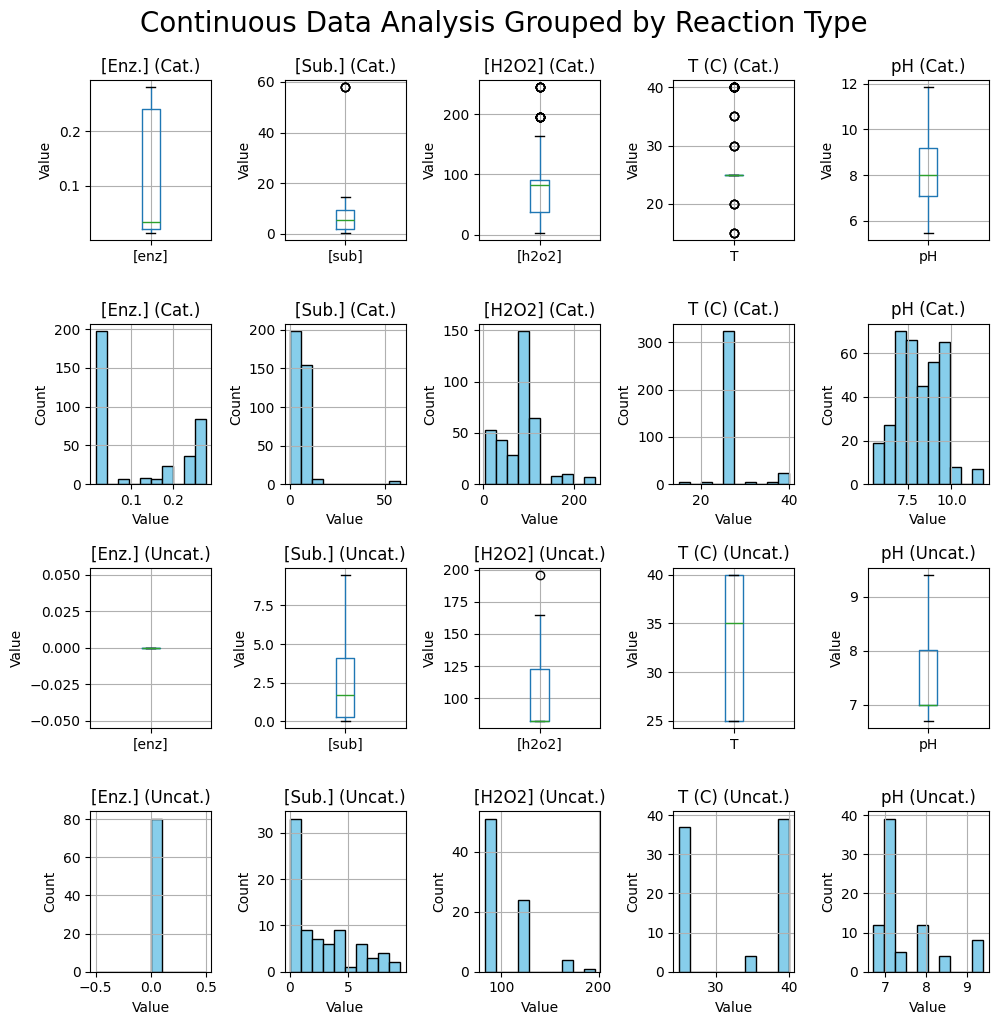

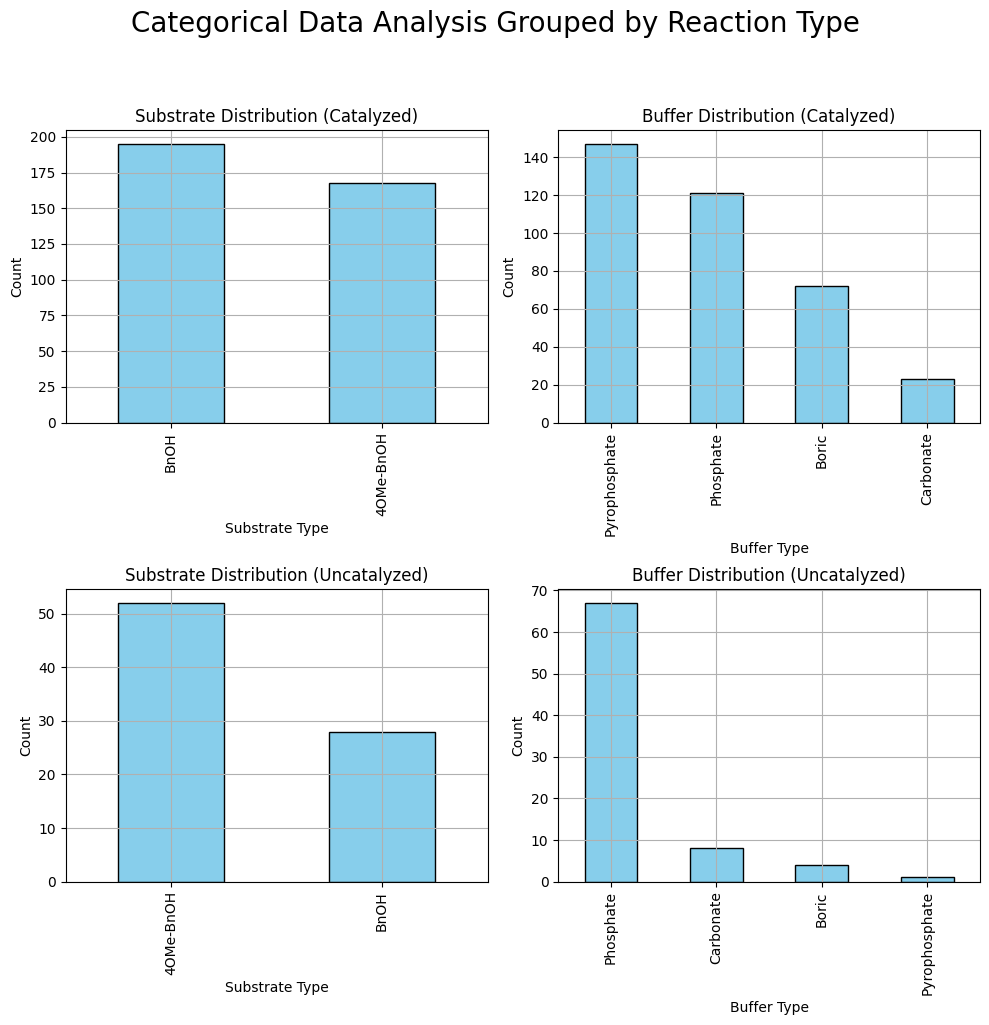

In [257]:
analyze_reaction_data(data_df_resampled)

## Clean data experimental data

In [258]:
# Correct the signs for the [P] values in experiment 50 and 78
experiment_to_correct = [50, 78]

for exp_num in experiment_to_correct:
    for idx, row in data_df_resampled[data_df_resampled["experiment"] == exp_num].iterrows():
        if isinstance(row["[P]"], dict) and "time" in row["[P]"] and "values" in row["[P]"]:
            # Flip the signs of the 'values' in the '[P]' dictionary
            data_df_resampled.at[idx, "[P]"]["values"] = [-v for v in row["[P]"]["values"]]

# remove the following experiments from the data
experiments_to_remove =[66, 84]
for exp_num in experiments_to_remove:
    data_df_resampled = data_df_resampled[data_df_resampled["experiment"] != exp_num]

# Remove the following experiment-sample pairs from the data
exp_num_sample_num = [[128, 2], [128, 3]]
for exp_num, sample_num in exp_num_sample_num:
    data_df_resampled = data_df_resampled[~((data_df_resampled["experiment"] == exp_num) & (data_df_resampled["sample"] == sample_num))]


In [527]:
def combined_sigmoid_mm_model(t, Km, A, k, t0, C):
    """
    Combined Michaelis-Menten and Sigmoidal model with a baseline shift (C).

    Args:
        t (array): Time points.
        Km (float): Half-saturation constant (MM component).
        A (float): Amplitude of the components.
        k (float): Growth rate of the sigmoidal component.
        t0 (float): Inflection point of the sigmoidal component.
        C (float): Baseline shift.

    Returns:
        array: Combined model predictions.
    """
    # Clip exponential argument for numerical stability
    exp_argument = -k * (t - t0)
    exp_argument_clipped = np.clip(exp_argument, -500, 500)

    # Michaelis-Menten component
    mm_part = (A * t) / (Km + t)

    # Sigmoidal component
    sigmoid_part = A / (1 + np.exp(exp_argument_clipped))

    # Return combined model with shift
    return mm_part + sigmoid_part + C

def fit_curves_to_data(
    dataframe,
    fit_range=None,
    plot=False,
    experiment_range=None,
    sample_range=None,
):
    """
    Fits [P](t) curves in a DataFrame using the sigmoid-MM model with a baseline shift (C) 
    and computes v0 (rate at t=0).

    Args:
        dataframe (pd.DataFrame): Input DataFrame containing [P](t) curves.
        fit_range (tuple): Range (start, end) in seconds to fit the curve. If None, fit the entire curve.
        plot (bool): If True, plots the original data and fitted curves.
        experiment_range (tuple): Range of experiments to include.
        sample_range (tuple): Range of samples to include.

    Returns:
        pd.DataFrame: DataFrame with additional columns for fitted functions and v0.
    """
    # Filter by experiment and sample ranges
    if experiment_range is not None:
        dataframe = dataframe[
            (dataframe["experiment"] >= experiment_range[0]) & 
            (dataframe["experiment"] <= experiment_range[1])
        ]
    if sample_range is not None:
        dataframe = dataframe[
            (dataframe["sample"] >= sample_range[0]) & 
            (dataframe["sample"] <= sample_range[1])
        ]

    # Ensure we don't modify the original DataFrame
    df = dataframe.copy()
    fitted_functions = []
    v0_values = []

    if plot:
        plt.figure(figsize=(12, 8))

    for _, row in df.iterrows():
        # Extract and preprocess data
        time_points = np.array(row["[P]"]["time"])
        P_values = np.array(row["[P]"]["values"])
        if fit_range:
            mask = (time_points >= fit_range[0]) & (time_points <= fit_range[1])
            time_points = time_points[mask]
            P_values = P_values[mask]
        
        t_min, t_max = time_points.min(), time_points.max()
        t_range = t_max - t_min
        time_points_scaled = (time_points - t_min) / t_range
        
        try:
            # Initial guesses
            slope = np.gradient(P_values, time_points_scaled)
            Km_guess = 0.5
            A_guess = max(P_values) - min(P_values)
            k_guess = 1.0
            t0_guess = 0.5
            C_guess = min(P_values)

            p0 = [Km_guess, A_guess, k_guess, t0_guess, C_guess]

            # Fit the model
            params, _ = curve_fit(
                combined_sigmoid_mm_model,
                time_points_scaled,
                P_values,
                p0=p0,
                bounds=([0, 0, 0, 0, -np.inf], [np.inf, np.inf, 50, 1, np.inf]),
                maxfev=100000
            )
            Km, A, k, t0, C = params
            print(f"Km: {Km:.4f}, A: {A:.4f}, k: {k:.4f}, t0: {t0:.4f}, C: {C:.4f}")

            # Define the fitted function
            fitted_function = lambda t: combined_sigmoid_mm_model(
                (t - t_min) / t_range, Km, A, k, t0, C
            )

            # Compute v0 (derivative at t=0)
            t_sym, Km_sym, A_sym, k_sym, t0_sym, C_sym = sp.symbols("t Km A k t0 C")
            mm_part = (A_sym * t_sym) / (Km_sym + t_sym)
            sigmoid_part = A_sym / (1 + sp.exp(-k_sym * (t_sym - t0_sym)))
            combined_model = mm_part + sigmoid_part + C_sym
            combined_model_derivative = sp.diff(combined_model, t_sym)
            derivative_func = sp.lambdify(
                [t_sym, Km_sym, A_sym, k_sym, t0_sym, C_sym],
                combined_model_derivative,
                modules="numpy"
            )
            v0 = derivative_func(0, Km, A, k, t0, C) / t_range
        except (RuntimeError, ValueError) as e:
            print(f"Fit failed for Experiment {row['experiment']}, Sample {row['sample']}: {e}")
            fitted_function = lambda t: np.nan * np.ones_like(t)
            v0 = np.nan

        # Ensure v0 is non-negative
        v0 = max(v0, 0)
        v0_values.append(v0)
        fitted_functions.append(fitted_function)

        # Plot the results
        if plot:
            fitted_time = np.linspace(0, t_max, 500)
            fitted_P = fitted_function(fitted_time)
            plt.scatter(time_points, P_values, label=f"Exp {row['experiment']} Sample {row['sample']} Data")
            plt.plot(fitted_time, fitted_P, label="Fit", alpha=0.8)

    # Add the results to the DataFrame
    df["fitted_function"] = fitted_functions
    df["v0"] = v0_values

    if plot:
        plt.xlabel("Time (s)")
        plt.ylabel("[P](t)")
        plt.title("Fitted Curves with Combined Sigmoid-MM Model")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    return df


Km: 1692.8925, A: 0.0004, k: 50.0000, t0: 0.4554, C: -0.0005
Km: 715838.0020, A: 0.0023, k: 5.2855, t0: 0.4770, C: -0.0004
Km: 26.4029, A: 0.0128, k: 2.6577, t0: 0.4575, C: -0.0035
Km: 288.5820, A: 0.0000, k: 0.0000, t0: 0.5036, C: 0.0006


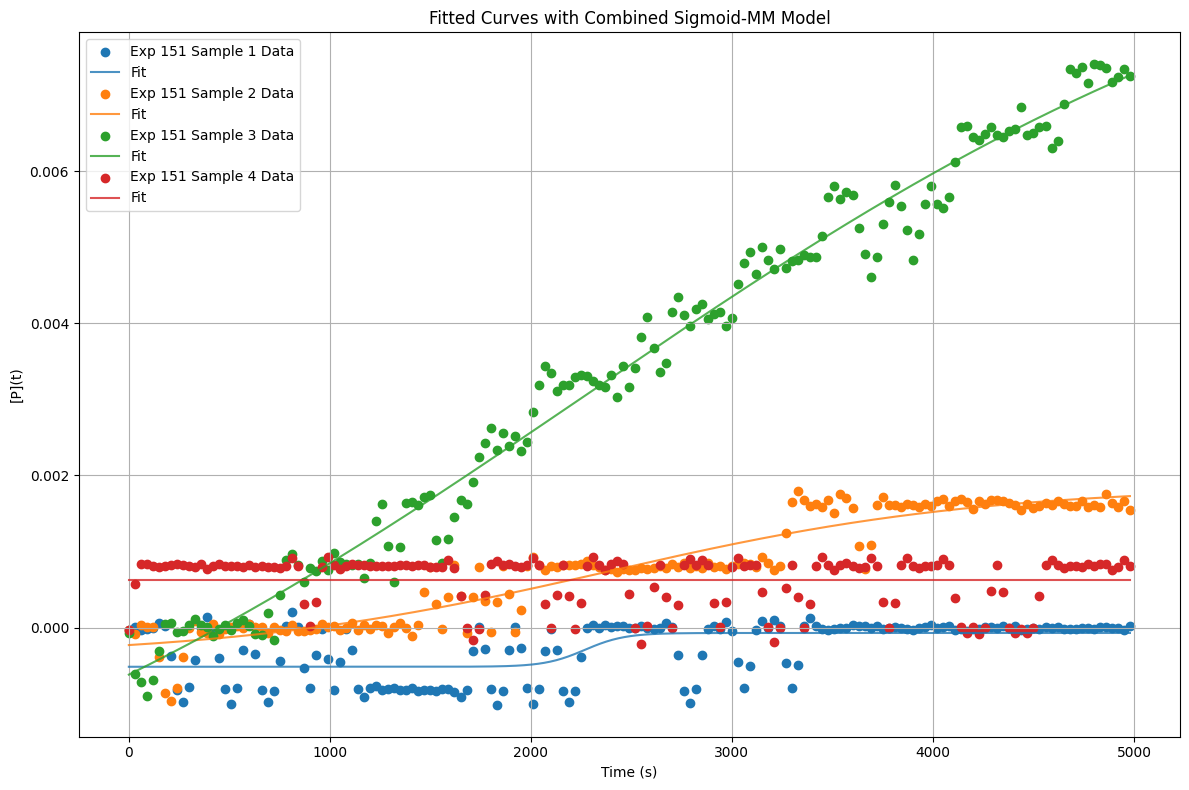

In [ ]:
fitted_df = fit_curves_to_data(
    dataframe=data_df_resampled,
    fit_range=(0, 5000),
    plot=True,
    
    experiment_range=(1,151),
    sample_range=(1,4),
)
# naughty list [[exp_num, sample_num], ...]
# [[128,2], [128,3], [13,1], [13,2]]

[5.26642052e-11 1.65147539e-07 1.29954417e-06 2.19261350e-18]


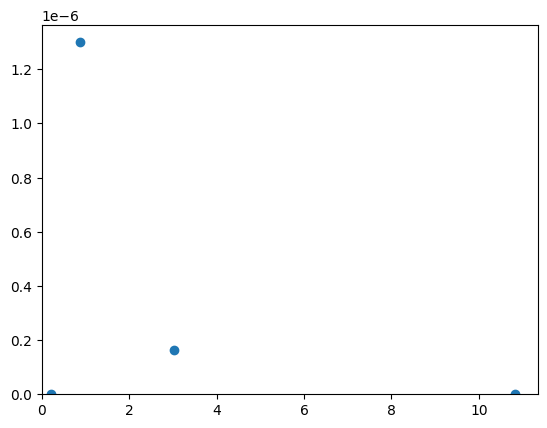

In [533]:
fitted_df.head()
v0 = np.array(fitted_df['v0'])
print(v0)


s0 = np.array(fitted_df['[sub]'])
# plot v0 vs s0
plt.scatter(s0, v0)
plt.xlim(0)
plt.ylim(0)

# fit a MM model to the data
from scipy.optimize import curve_fit


In [262]:
fitted_df.head()

,experiment,sample,substrate,abs,e,buffer,pH,T,[enz],[h2o2],[sub],[P],fitted_function,v0
155,128,1,4OMe-BnOH,300,7.53,Pyrophosphate,7.29,25,0.032,195.882,9.47,"{'time': [0.0, 30.0, 60.0, 90.0, 120.0, 150.0,...",<function fit_curves_to_data.<locals>.<lambda>...,3.016457e+05
158,128,4,4OMe-BnOH,300,7.53,Pyrophosphate,7.29,25,0.032,3.879,9.47,"{'time': [0.0, 30.0, 60.0, 90.0, 120.0, 150.0,...",<function fit_curves_to_data.<locals>.<lambda>...,5.387930e-08


In [263]:
def replace_numeric_constants(eq):
    """
    Replaces numeric constants in a symbolic equation with symbolic parameters.

    Args:
        eq (sympy.Expr): The symbolic equation.
results = discover_and_apply_time_function(
    dataframe=experiment_df,
    experiment_range=(146, 146),
    sample_range=(4, 4),
    time_range=(0, 50000),
    niterations=100,
    popsize=200,
    maxsize=7
)

# Updated DataFrame
updated_df = results["dataframe"]

    Returns:
        sympy.Expr: The equation with numeric constants replaced by parameters.
        list: List of symbolic parameters introduced.
    """
    constants = []
    constant_map = {}
    for num in eq.atoms(sp.Number):
        if num != 0:  # Exclude zero
            param = sp.symbols(f"param_{len(constants)}")
            constant_map[num] = param
            constants.append(param)
    eq_with_params = eq.subs(constant_map)
    return eq_with_params, constants


def discover_individual_time_functions(dataframe, experiment_range=None, sample_range=None, 
                                       time_range=None, niterations=40, popsize=50, maxsize=10):
    """
    Uses PySR to discover individual differentiable fitting functions for time-based [P](t) curves
    in the DataFrame and saves the refitted equations for each curve.

    Args:
        dataframe (pd.DataFrame): DataFrame containing experimental data, including [P](t) curves.
        experiment_range (tuple): Range of experiments to process (min_experiment, max_experiment).
                                  If None, processes all experiments.
        sample_range (tuple): Range of samples to process (min_sample, max_sample).
                              If None, processes all samples.
        time_range (tuple): Range of time points to include (min_time, max_time). If None, includes all time points.
        niterations (int): Number of optimization iterations for PySR.
        popsize (int): Population size for the genetic algorithm in PySR.
        maxsize (int): Maximum size of symbolic equations.

    Returns:
        pd.DataFrame: Updated DataFrame with a new column 'refitted_equation' containing individual fitted equations.
    """
    # Filter by experiment range if provided
    if experiment_range is not None:
        min_exp, max_exp = experiment_range
        dataframe = dataframe[(dataframe["experiment"] >= min_exp) & (dataframe["experiment"] <= max_exp)]
    
    # Filter by sample range if provided
    if sample_range is not None:
        min_sample, max_sample = sample_range
        dataframe = dataframe[(dataframe["sample"] >= min_sample) & (dataframe["sample"] <= max_sample)]

    # Initialize a column for storing individual equations
    refitted_equations = []

    # Iterate over each row to fit a unique equation to each curve
    for _, row in dataframe.iterrows():
        try:
            time_points = np.array(row["[P]"]["time"])  # Extract time points
            P_values = np.array(row["[P]"]["values"])  # Extract [P](t) values

            # Apply time range filter if specified
            if time_range is not None:
                min_time, max_time = time_range
                mask = (time_points >= min_time) & (time_points <= max_time)
                time_points = time_points[mask]
                P_values = P_values[mask]

            # Skip if no valid data points
            if len(time_points) == 0 or len(P_values) == 0:
                refitted_equations.append(None)
                continue

            # Define the PySR model
            model = PySRRegressor(
                niterations=niterations,
                binary_operators=["+", "-", "*", "/"],  # Basic operators
                unary_operators=["exp", "log", "sqrt"],  # Additional differentiable functions
                # extra_sympy_mappings={"exp": "exp"},  # Map "exp" to its symbolic representation
                loss="loss(x, y) = (x - y)^2",  # Mean squared error
                population_size=popsize,
                maxsize=maxsize,
                verbosity=0,  # Silence output for each individual fit
                random_state=42,
            )

            # Fit the model to the curve
            model.fit(time_points.reshape(-1, 1), P_values)

            # Extract the best equation and convert to symbolic form
            best_equation = model.get_best()["equation"]
            symbolic_equation = sp.sympify(best_equation)

            # Replace numeric constants in the equation with symbolic parameters
            parameterized_equation, constants = replace_numeric_constants(symbolic_equation)

            # Refit the parameterized equation to the individual curve
            x = sp.symbols("x0")  # Symbolic variable for time
            func = sp.lambdify((x, *constants), parameterized_equation, modules="numpy")

            # Fit the parameterized symbolic equation to the data
            initial_guess = [1.0] * len(constants)
            params, _ = curve_fit(lambda t, *params: func(t, *params), time_points, P_values, p0=initial_guess)

            # Generate the refitted equation by substituting fitted parameters
            refitted_eq = parameterized_equation.subs({c: p for c, p in zip(constants, params)})
            refitted_equations.append(refitted_eq)

        except Exception as e:
            print(f"Error processing Experiment {row['experiment']}, Sample {row['sample']}: {e}")
            refitted_equations.append(None)

    # Add the refitted equations as a new column to the DataFrame
    dataframe["refitted_equation"] = refitted_equations

    return dataframe

In [264]:
updated_df = discover_individual_time_functions(
    dataframe=experiment_df_with_resampled,
    experiment_range=(146, 146),  # For example, process experiment 146
    sample_range=(1, 1),          # For example, process samples 1 through 3
    time_range=(0, 3000),         # Use all time points within 0 to 3000 seconds
    niterations=200,
    popsize=100,
    maxsize=10
)


NameError: name 'experiment_df_with_resampled' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

def plot_refitted_curves(dataframe=updated_df, time_range=None, plot_title="Refitted Curves and Data Points"):
    """
    Plots the experimental data points and their corresponding refitted curves.

    Args:
        dataframe (pd.DataFrame): The DataFrame containing experimental data and refitted equations.
        time_range (tuple): Range of time points to plot (min_time, max_time). If None, uses full range.
        plot_title (str): Title for the plot (default: "Refitted Curves and Data Points").
    """
    plt.figure(figsize=(10, 6))

    for _, row in dataframe.iterrows():
        try:
            time_points = np.array(row["[P]"]["time"])
            P_values = np.array(row["[P]"]["values"])
            refitted_eq = row["refitted_equation"]

            # Ensure the refitted equation is a symbolic expression
            if refitted_eq is None or not isinstance(refitted_eq, sp.Basic):
                print(f"No valid refitted equation for Experiment {row['experiment']}, Sample {row['sample']}")
                continue

            # Apply time range filter if specified
            if time_range is not None:
                min_time, max_time = time_range
                mask = (time_points >= min_time) & (time_points <= max_time)
                time_points = time_points[mask]
                P_values = P_values[mask]

            # Skip empty or filtered-out data
            if len(time_points) == 0 or len(P_values) == 0:
                print(f"No valid data points for Experiment {row['experiment']}, Sample {row['sample']}")
                continue

            # Generate the function from the refitted equation
            x = sp.symbols("x0")  # Symbolic variable for time
            refitted_func = sp.lambdify(x, refitted_eq, modules="numpy")

            # Generate smooth time points for the refitted curve
            smooth_time = np.linspace(time_points.min(), time_points.max(), 500)
            refitted_values = refitted_func(smooth_time)

            # Plot the experimental data points
            plt.scatter(time_points, P_values, label=f"Exp {row['experiment']}, Sample {row['sample']} (Data)", s=10)

            # Plot the refitted curve
            plt.plot(smooth_time, refitted_values, label=f"Exp {row['experiment']}, Sample {row['sample']} (Fit)")

        except Exception as e:
            print(f"Error processing Experiment {row['experiment']}, Sample {row['sample']}: {e}")

    # Customize plot
    plt.xlabel("Time (s)")
    plt.ylabel("[P]")
    plt.title(plot_title)
    plt.legend(fontsize="small", loc="best")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


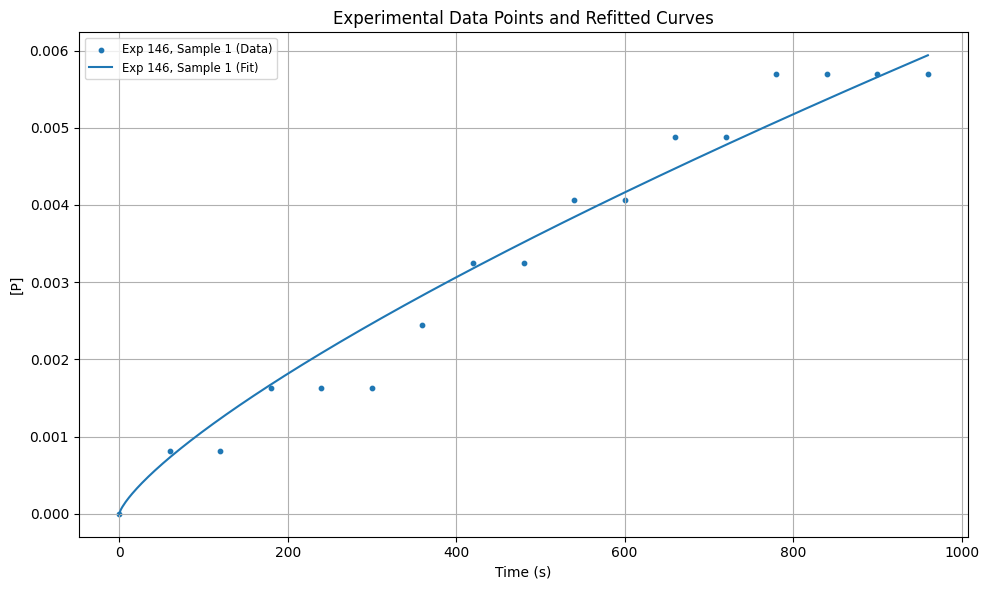

In [ ]:
plot_refitted_curves(
    dataframe=updated_df,
    time_range=(0, 1000),
    plot_title="Experimental Data Points and Refitted Curves"
)
